In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import numpy as np

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
train_filter=np.where((y_train==0) | (y_train==1))
test_filter=np.where((y_test==0) | (y_test==1))

In [ ]:
x_train,y_train=x_train[train_filter],y_train[train_filter]
x_test,y_test=x_test[test_filter],y_test[test_filter]

In [ ]:
x_train=x_train.reshape(x_train.shape[0], -1)/255.0

x_test=x_test.reshape(x_test.shape[0], -1)/255.0

In [ ]:
model=tf.keras.Sequential([
    tf.keras.layers.Dense(1,input_shape=(784,),activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
model.fit(x_train,y_train, epochs=10, batch_size=32, validation_data=(x_test,y_test))

Epoch 1/10
396/396 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9882 - loss: 0.0945 - val_accuracy: 0.9995 - val_loss: 0.0195
Epoch 2/10
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9973 - loss: 0.0184 - val_accuracy: 0.9995 - val_loss: 0.0088
Epoch 3/10
396/396 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9981 - loss: 0.0110 - val_accuracy: 0.9995 - val_loss: 0.0056
Epoch 4/10
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9983 - loss: 0.0080 - val_accuracy: 0.9995 - val_loss: 0.0042
Epoch 5/10
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9984 - loss: 0.0064 - val_accuracy: 0.9995 - val_loss: 0.0035
Epoch 6/10
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9987 - loss: 0.0053 - val_accuracy: 0.9995 - val_loss: 0.0029
Epoch 7/10
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9989 - loss: 0.0046 - val_accuracy: 0.9995 - val_loss: 0.0026
Epoch 8/10
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9988 - loss: 0.0041 - val_accuracy: 0.

In [ ]:
#test_loss, tes_acc=model.evaluates(x_test,y_test)
#print(f"\nTest Accuracy:"{test_acc:.4f}")

In [ ]:
#Overfitting vs Underfitting
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt


In [ ]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x_train, x_test=x_train/255.0, x_test/255.0

x_train=x_train.reshape(-1, 784)
x_test=x_test.reshape(-1, 784)

In [ ]:
#undefitting model

underfit_model=tf.keras.Sequential([
    tf.keras.layers.Dense(16, input_shape=(784,), activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

underfit_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])



In [ ]:
#overfitting model

overfit_model=tf.keras.Sequential([
    tf.keras.layers.Dense(512,activation='relu', input_shape=(784,)),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(10,activation='softmax')
    ])

In [ ]:
overfit_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
#good fit model

good_model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(10, activation='softmax')
])




In [ ]:
good_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history_under = underfit_model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test, y_test),
    verbose=0
)

history_over = overfit_model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test, y_test),
    verbose=0
)

history_good = good_model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test, y_test),
    verbose=0
)

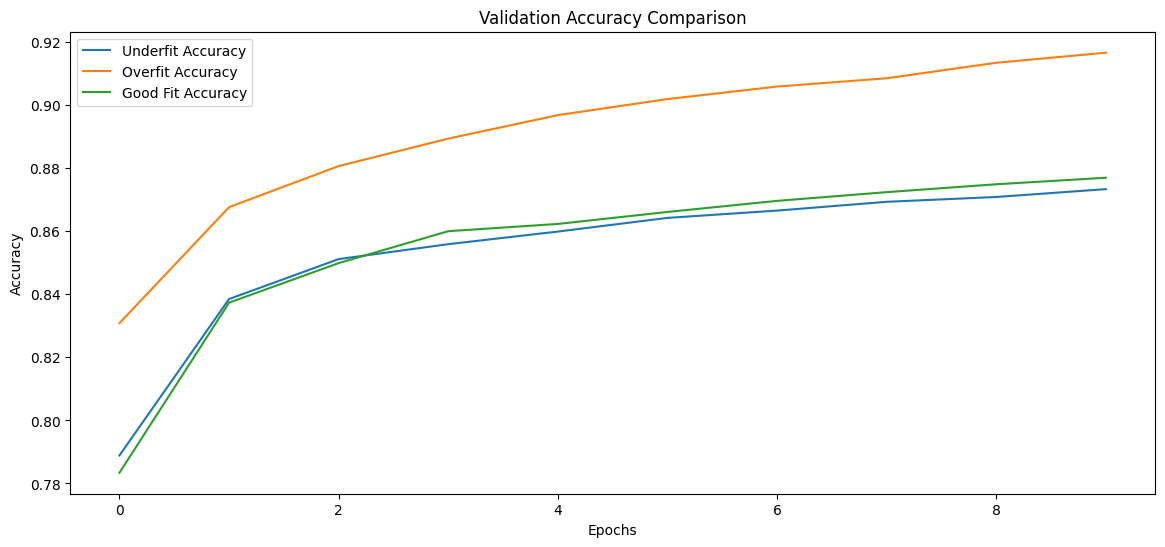

In [ ]:
#plot accuracy curves

plt.figure(figsize=(14,6))

plt.plot(history_under.history['accuracy'], label='Underfit Accuracy')
plt.plot(history_over.history['accuracy'], label='Overfit Accuracy')
plt.plot(history_good.history['accuracy'], label='Good Fit Accuracy')

plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
#tensorflow intro

import tensorflow as tf
version = tf.__version__
print(version)

2.20.0


In [ ]:
mnist=tf.keras.datasets.fashion_mnist

In [ ]:
(training_images, training_labels), (test_images, test_labels)=mnist.load_data()

9
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1   1   0 200 232 

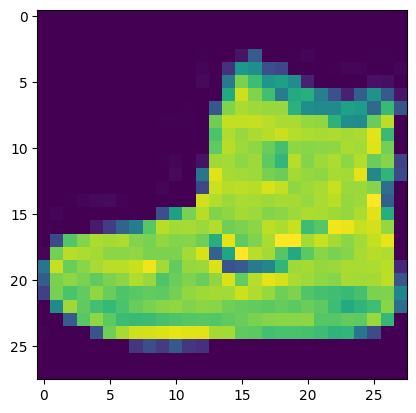

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(training_images[0])
print(training_labels[0])
print(training_images[0])

In [ ]:
training_images=training_images/255.0
test_images=test_images/255.0

In [ ]:
model=tf.keras.models.Sequential([tf.keras.layers.Flatten(),
                                 tf.keras.layers.Dense(128, activation=tf.nn.relu),
                                 tf.keras.layers.Dense(10, activation=tf.nn.softmax)])

In [ ]:
model.compile(optimizer=tf.optimizers.Adam(),
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])
model.fit(training_images, training_labels, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8255 - loss: 0.4995
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8660 - loss: 0.3737
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8774 - loss: 0.3361
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8868 - loss: 0.3121
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8909 - loss: 0.2955


In [ ]:
model.evaluate(test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8761 - loss: 0.3476


[0.34762486815452576, 0.8761000037193298]

In [ ]:
classification=model.predict(test_images)
print(classifications[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


NameError: name 'classifications' is not defined